In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("../data/q2_customers.csv")

# Check data
df.head()

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [3]:
### Data Preparation

#- All features are scaled using StandardScaler.
#- Scaling is important for K-Means because it is distance-based.
#- Without scaling, features with larger values dominate clustering.

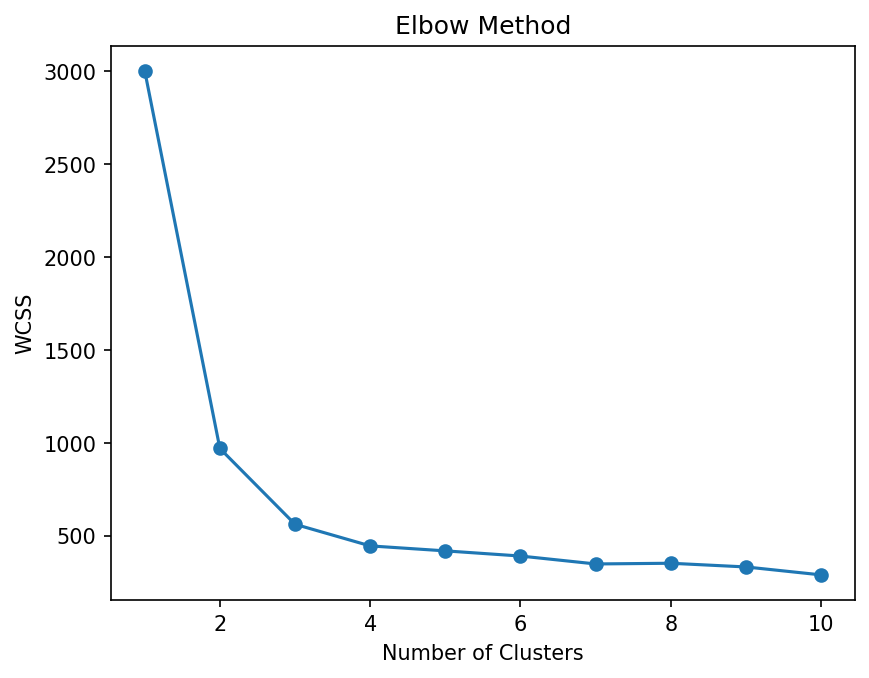

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(dpi=150)
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
### Elbow Method

#- The elbow point indicates optimal number of clusters.
#- After that point, reduction in WCSS slows down.
#- Selected optimal K = (mention based on graph).

In [21]:
# Choose K (example: 3)
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
df['cluster'] = clusters

# Cluster centers
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                         columns=df.columns[:-1])

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


In [23]:
from sklearn.decomposition import PCA

# Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Create DataFrame for PCA
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Add cluster labels
pca_df['cluster'] = clusters

pca_df.head()

Explained Variance Ratio: [0.83560354 0.05568764]


,PC1,PC2,cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0


In [25]:
### PCA Interpretation

#- PCA reduces the dataset into 2 principal components (PC1 and PC2).
#- These components capture most of the variance in the data.
#- This helps in visualizing high-dimensional data in 2D space.

In [29]:
# Feature loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.drop('cluster',axis=1).columns,
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


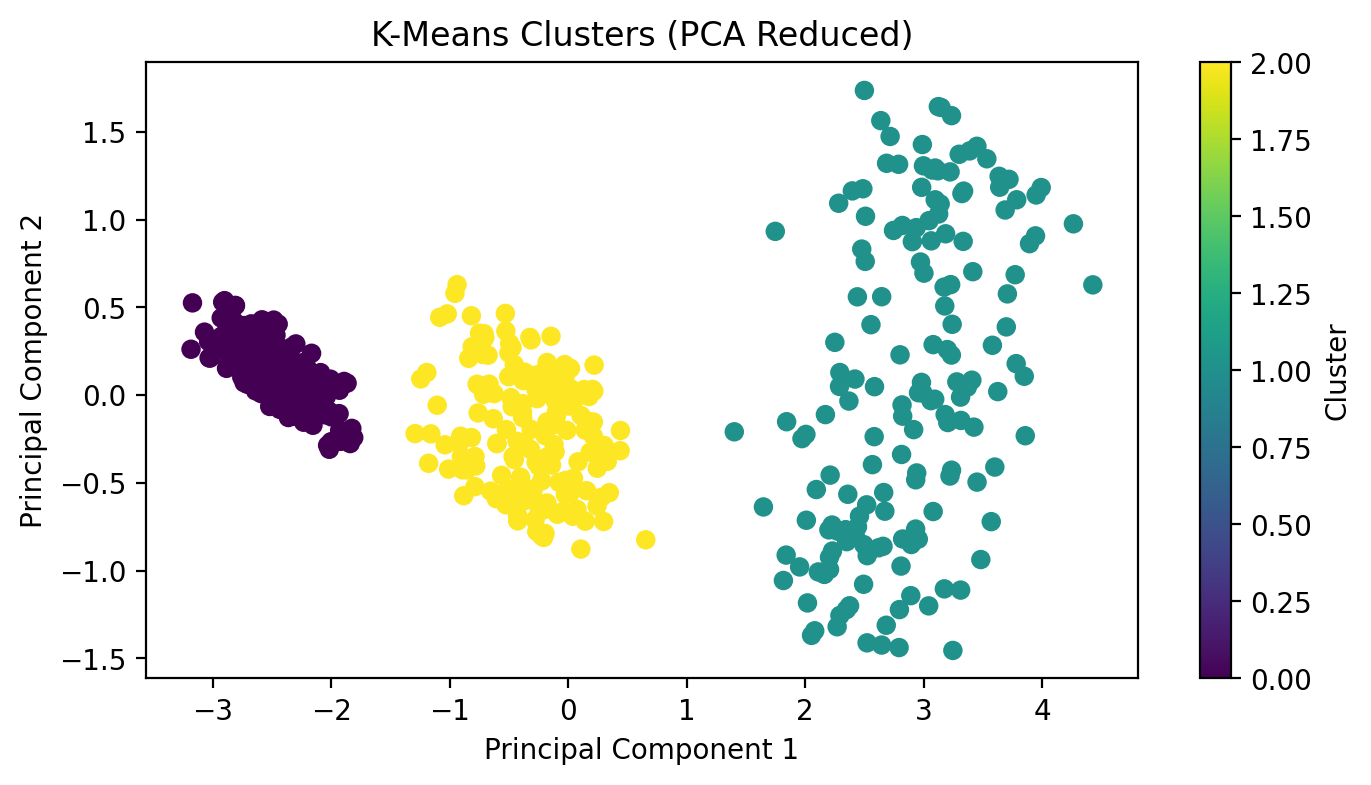

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4),dpi=200)

plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['cluster'])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA Reduced)")
plt.colorbar(label='Cluster')

plt.show()

In [53]:
### Cluster Visualization

#- The scatter plot shows clusters in 2D space using PCA.
#- Each color represents a different cluster.
#- Clear separation indicates effective clustering.